### Strategy 1st try 

Investment horizon : 5 days 

Strategy 1: 
Compare predicted volatility to avg. volatility 
Open Butterfly long if pred_vol < avg_vol

Strategy 2: 
Compare predicted volatility to implied volatility
Open Butterfly long if pred_vol < IV





In [1]:
# %pip install py_vollib

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from py_vollib.black_scholes import black_scholes
from scipy.stats import percentileofscore
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import yfinance as yf
from py_vollib.black_scholes import implied_volatility
import datetime as dt
import pytz

#### Data import 

data requirements: 

options_data = options_data # DataFrame with columns: timestamp, expiration_date, strike_price, type, opt_close, dtm, SPY_close, volume, open_interest


underlying_data = underlying_data # DataFrame with columns: timestamp, close, volume

vol_predictions = vol_predictions # DataFrame with columns: prediction_day, predicted_day, predicted_vol

In [3]:
# load data 

underlying_data= pd.read_csv(r"C:\Users\pauli\Butterflies-\yfinance_data\spy.csv")

vol_predictions = pd.read_csv(r"C:\Users\pauli\Butterflies-\model\predictions\0.csv")

options_data = pd.read_csv(r"C:\Users\pauli\Butterflies-\options\options.csv")

In [4]:
# Underlying data
underlying_data = underlying_data.iloc[2:]
underlying_data = underlying_data.rename(columns={'Price' : 'timestamp', 'Close' : 'close', 'Volume' : 'volume'})

# fix datetime and UTC issues 
underlying_data['timestamp'] = pd.to_datetime(underlying_data['timestamp'])
underlying_data['timestamp'] = underlying_data['timestamp'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

# Numeric values
underlying_data['close'] = pd.to_numeric(underlying_data['close'], errors='coerce')
underlying_data['volume'] = pd.to_numeric(underlying_data['volume'], errors='coerce')


In [5]:
options_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142540 entries, 0 to 142539
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      142540 non-null  int64  
 1   symbol                          142540 non-null  object 
 2   date                            142540 non-null  object 
 3   opt_close                       142540 non-null  float64
 4   volume                          142540 non-null  float64
 5   trade_count                     142540 non-null  float64
 6   vwap                            142540 non-null  float64
 7   expiration_date                 142540 non-null  object 
 8   strike_price                    142540 non-null  float64
 9   size                            142540 non-null  int64  
 10  type                            142540 non-null  object 
 11  style                           142540 non-null  object 
 12  open_interest   

In [6]:
# Options data
options_data= options_data.rename(columns={'close' : 'opt_close', 'date': "timestamp", 'close_price' : 'close_price_on_expiry'}) 
options_data['expiration_date'] = pd.to_datetime(options_data['expiration_date'])
options_data['timestamp'] = pd.to_datetime(options_data['timestamp'])
options_data["open_interest_date"] = pd.to_datetime(options_data["open_interest_date"])
options_data["close_price_date"] = pd.to_datetime(options_data["close_price_date"])


# add UTC to timestamps 

options_data["timestamp"] = options_data["timestamp"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data['expiration_date'] = options_data['expiration_date'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data["close_price_date"] = options_data["close_price_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data["open_interest_date"] = options_data["open_interest_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

# calculate dtm 
options_data['dtm'] = options_data.apply(
    lambda row: np.busday_count(row['timestamp'].date(), row['expiration_date'].date()),
    axis=1
)    #trading_days_to_expiry


# Numeric values 
options_data['opt_close'] = pd.to_numeric(options_data['opt_close'], errors='coerce')
options_data['open_interest'] = pd.to_numeric(options_data['open_interest'], errors='coerce')
options_data['volume'] = pd.to_numeric(options_data['volume'], errors='coerce')
options_data['strike_price'] = pd.to_numeric(options_data['strike_price'], errors='coerce')


In [7]:
# for day in options_data['timestamp'].dt.date.unique():
#     expiry_candidates = options_data[
#                         (options_data['timestamp'].dt.date == day) & (options_data['dtm'] == 5)
#                     ]['expiration_date'].unique()
#     print(f"Expiry candidates for {day}: {expiry_candidates}")

options_data_ana = options_data[["timestamp", "symbol", "expiration_date", "strike_price", "opt_close", "dtm"]]
options_data_ana[(options_data_ana['timestamp'] == "2024-03-05 05:00:00+00:00")].sort_values(by="expiration_date", ascending=True).tail(20)
options_data_ana[(options_data_ana['symbol'] == "SPY240312P00475000")].sort_values(by="timestamp", ascending=True)

,timestamp,symbol,expiration_date,strike_price,opt_close,dtm
1358,2024-03-05 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.13,5
1359,2024-03-06 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.06,4
1360,2024-03-07 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.04,3
1361,2024-03-08 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.03,2
1362,2024-03-11 05:00:00+00:00,SPY240312P00475000,2024-03-12 05:00:00+00:00,475.0,0.01,1


In [8]:
# Vola predictions adjustments
# columns to numeric values


vol_predictions["prediction_day"] = pd.to_datetime(vol_predictions['prediction_day'])
vol_predictions["predicted_day"] = pd.to_datetime(vol_predictions['predicted_day'])

#fix utc issues 


vol_predictions["prediction_day"] = vol_predictions["prediction_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
vol_predictions["predicted_day"] = vol_predictions["predicted_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

vol_predictions["prediction_day"] = vol_predictions["prediction_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
vol_predictions["predicted_day"] = vol_predictions["predicted_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)


vol_predictions = vol_predictions.rename(columns={'predicted_vola': 'predicted_vol'})
vol_predictions['predicted_vol'] = pd.to_numeric(vol_predictions['predicted_vol'], errors='coerce')


In [9]:
vol_predictions
#options_data
#underlying_data

,Unnamed: 0,predicted_vol,prediction_day,predicted_day
0,0,0.137054,2024-04-30 05:00:00+00:00,2024-05-07 05:00:00+00:00
1,1,0.138821,2024-05-01 05:00:00+00:00,2024-05-08 05:00:00+00:00
2,2,0.152645,2024-05-02 05:00:00+00:00,2024-05-09 05:00:00+00:00
3,3,0.146508,2024-05-03 05:00:00+00:00,2024-05-10 05:00:00+00:00
4,4,0.126144,2024-05-06 05:00:00+00:00,2024-05-13 05:00:00+00:00
...,...,...,...,...
263,263,0.125516,2025-05-19 05:00:00+00:00,2025-05-27 05:00:00+00:00
264,264,0.132009,2025-05-20 05:00:00+00:00,2025-05-28 05:00:00+00:00
265,265,0.136500,2025-05-21 05:00:00+00:00,2025-05-29 05:00:00+00:00
266,266,0.159679,2025-05-22 05:00:00+00:00,2025-05-30 05:00:00+00:00


In [10]:
# filter timestamps for all dataframes based on the available options 

start_time = '2024-04-01 05:00:00+00:00'
end_time = '2024-06-01 05:00:00+00:00'
options_data =  options_data[(options_data['timestamp'] >= start_time) & (options_data['timestamp'] <= end_time)]

start_date = options_data['timestamp'].min()
end_date = options_data['timestamp'].max()



vol_predictions = vol_predictions[(vol_predictions['prediction_day'] >= start_date) & (vol_predictions['prediction_day'] <= end_date)]
underlying_data = underlying_data[(underlying_data['timestamp'] >= start_date) & (underlying_data['timestamp'] <= end_date)]

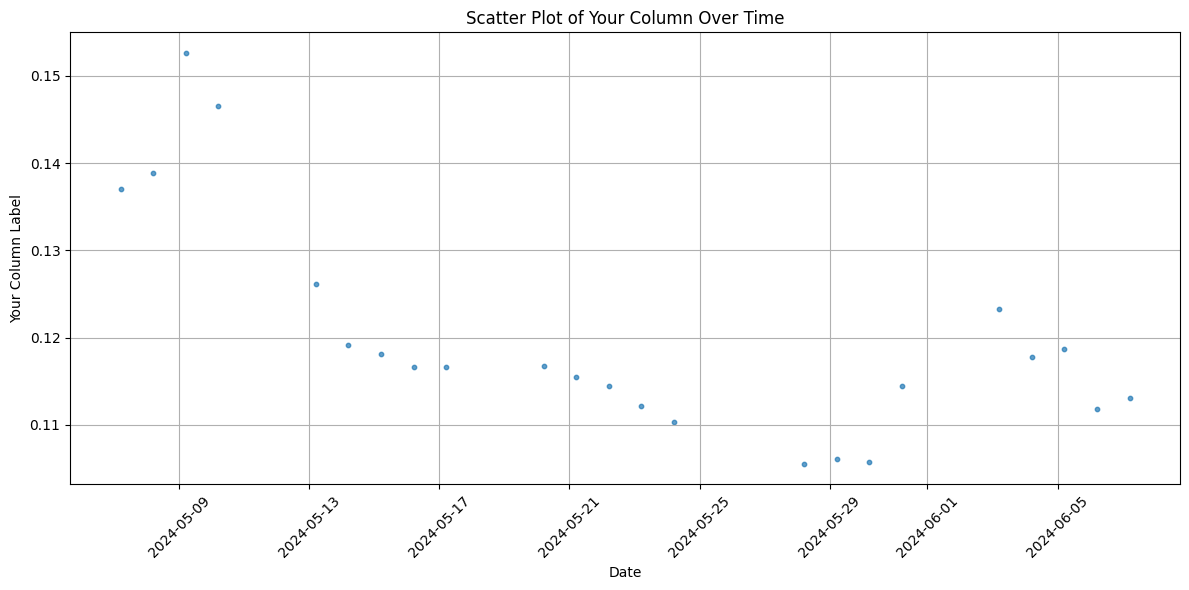

In [11]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(vol_predictions['predicted_day'], vol_predictions['predicted_vol'], s=10, alpha=0.7)
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Your Column Label')
plt.title('Scatter Plot of Your Column Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# from Butterfly_long_backtest import ButterflyBacktest



# # Make sure your DataFrames are loaded and preprocessed:
# # options_data, underlying_data, vol_predictions

# # Instantiate the backtest class
# bt = ButterflyBacktest(
#     options_data=options_data,
#     underlying_data=underlying_data,
#     vol_predictions=vol_predictions,  
#     spread_pct=1,                     # pct of the underlying price to set the spread width
#     commission=1.0,                   # teke into account commission costs
#     slippage=0.01,                    # take into account slippage
#     min_open_interest=0,             # ensure sufficient open interest
#     min_volume=1,                     # ensure sufficient liquidity
#     vol_exit_threshold=10            # exit if the predicted volatility changes by more than this percentage
# )

# # Run the backtest
# results_df, equity_df = bt.run(option_type='call', starting_cash=1000)

# # Display results
# print(results_df.head())
# print(equity_df.head())

In [13]:
options_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20801 entries, 7541 to 29428
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype              
---  ------                          --------------  -----              
 0   Unnamed: 0                      20801 non-null  int64              
 1   symbol                          20801 non-null  object             
 2   timestamp                       20801 non-null  datetime64[ns, UTC]
 3   opt_close                       20801 non-null  float64            
 4   volume                          20801 non-null  float64            
 5   trade_count                     20801 non-null  float64            
 6   vwap                            20801 non-null  float64            
 7   expiration_date                 20801 non-null  datetime64[ns, UTC]
 8   strike_price                    20801 non-null  float64            
 9   size                            20801 non-null  int64              
 10  type        

Total dates to process: 44
Sample underlying_data['timestamp']: [Timestamp('2024-04-01 05:00:00+0000', tz='UTC'), Timestamp('2024-04-02 05:00:00+0000', tz='UTC'), Timestamp('2024-04-03 05:00:00+0000', tz='UTC'), Timestamp('2024-04-04 05:00:00+0000', tz='UTC'), Timestamp('2024-04-05 05:00:00+0000', tz='UTC'), Timestamp('2024-04-08 05:00:00+0000', tz='UTC'), Timestamp('2024-04-09 05:00:00+0000', tz='UTC'), Timestamp('2024-04-10 05:00:00+0000', tz='UTC'), Timestamp('2024-04-11 05:00:00+0000', tz='UTC'), Timestamp('2024-04-12 05:00:00+0000', tz='UTC')]
Processing day: 2024-04-01
Found expiry candidates: 1 for day 2024-04-01
Options for 2024-04-01: 29 strikes: [490. 495. 498. 500. 505. 510. 511. 512. 513. 514. 515. 516. 517. 518.
 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 535.
 540.]
Constructed LONG butterfly on 2024-04-01 05:00:00+00:00: 
Constructed SHORT butterfly on 2024-04-01 05:00:00+00:00: 
Sample underlying_data['timestamp']: [Timestamp('2024-04-01 05:00:00+0

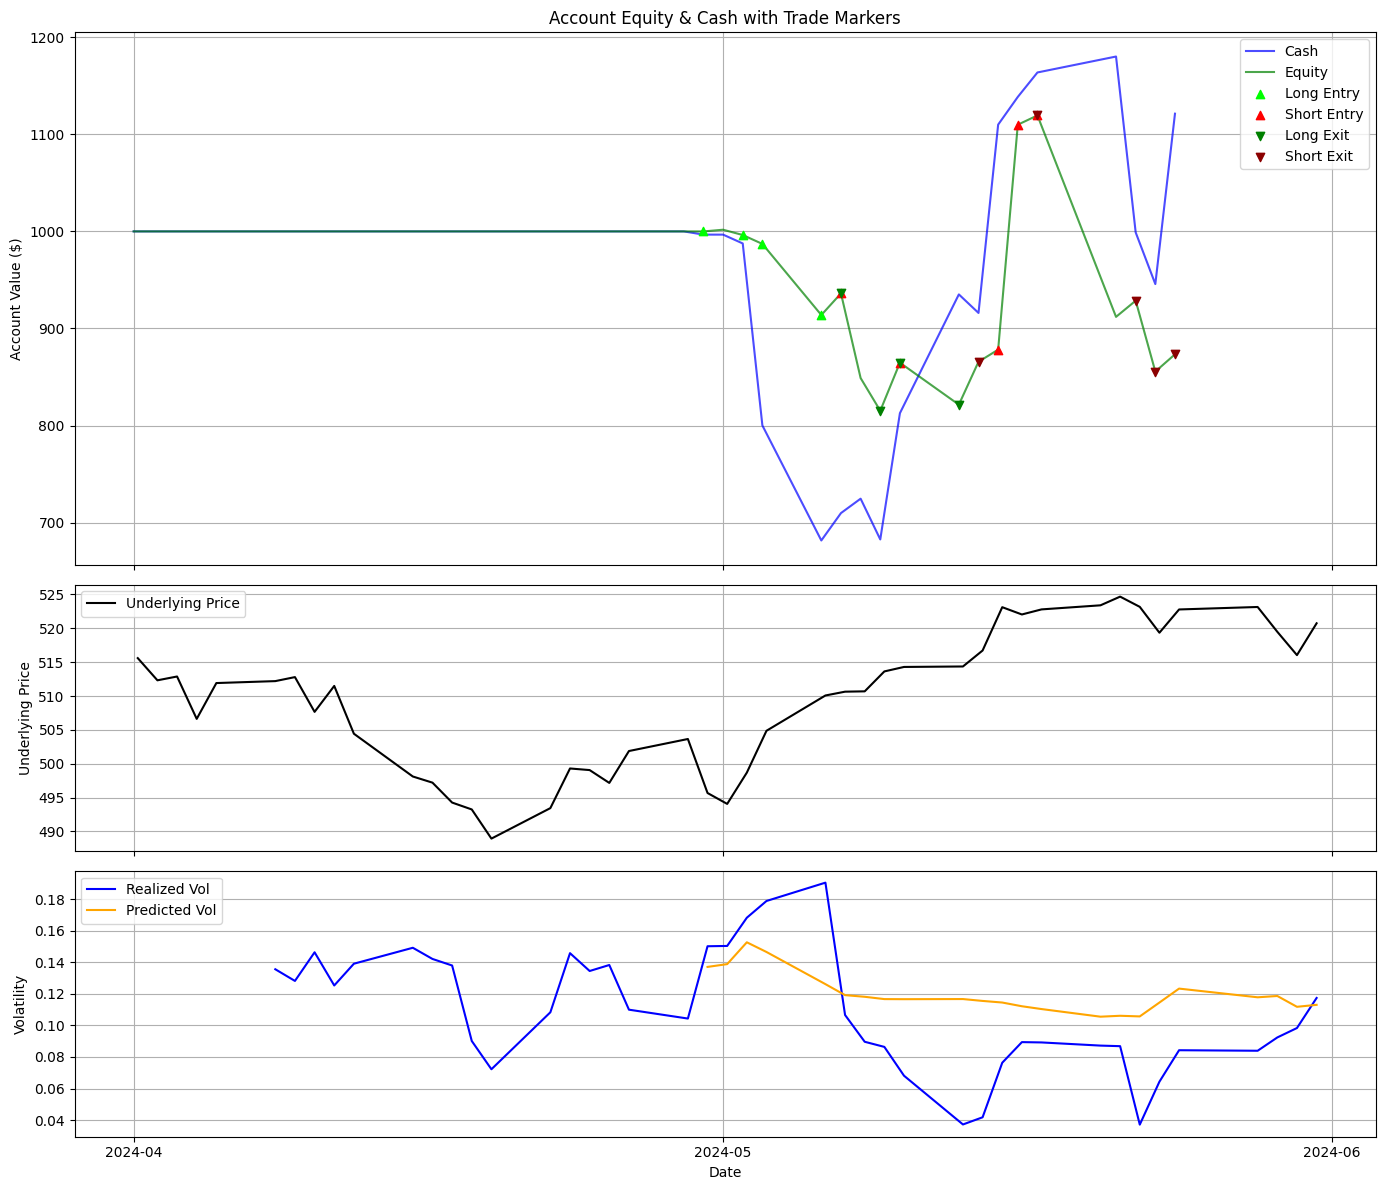

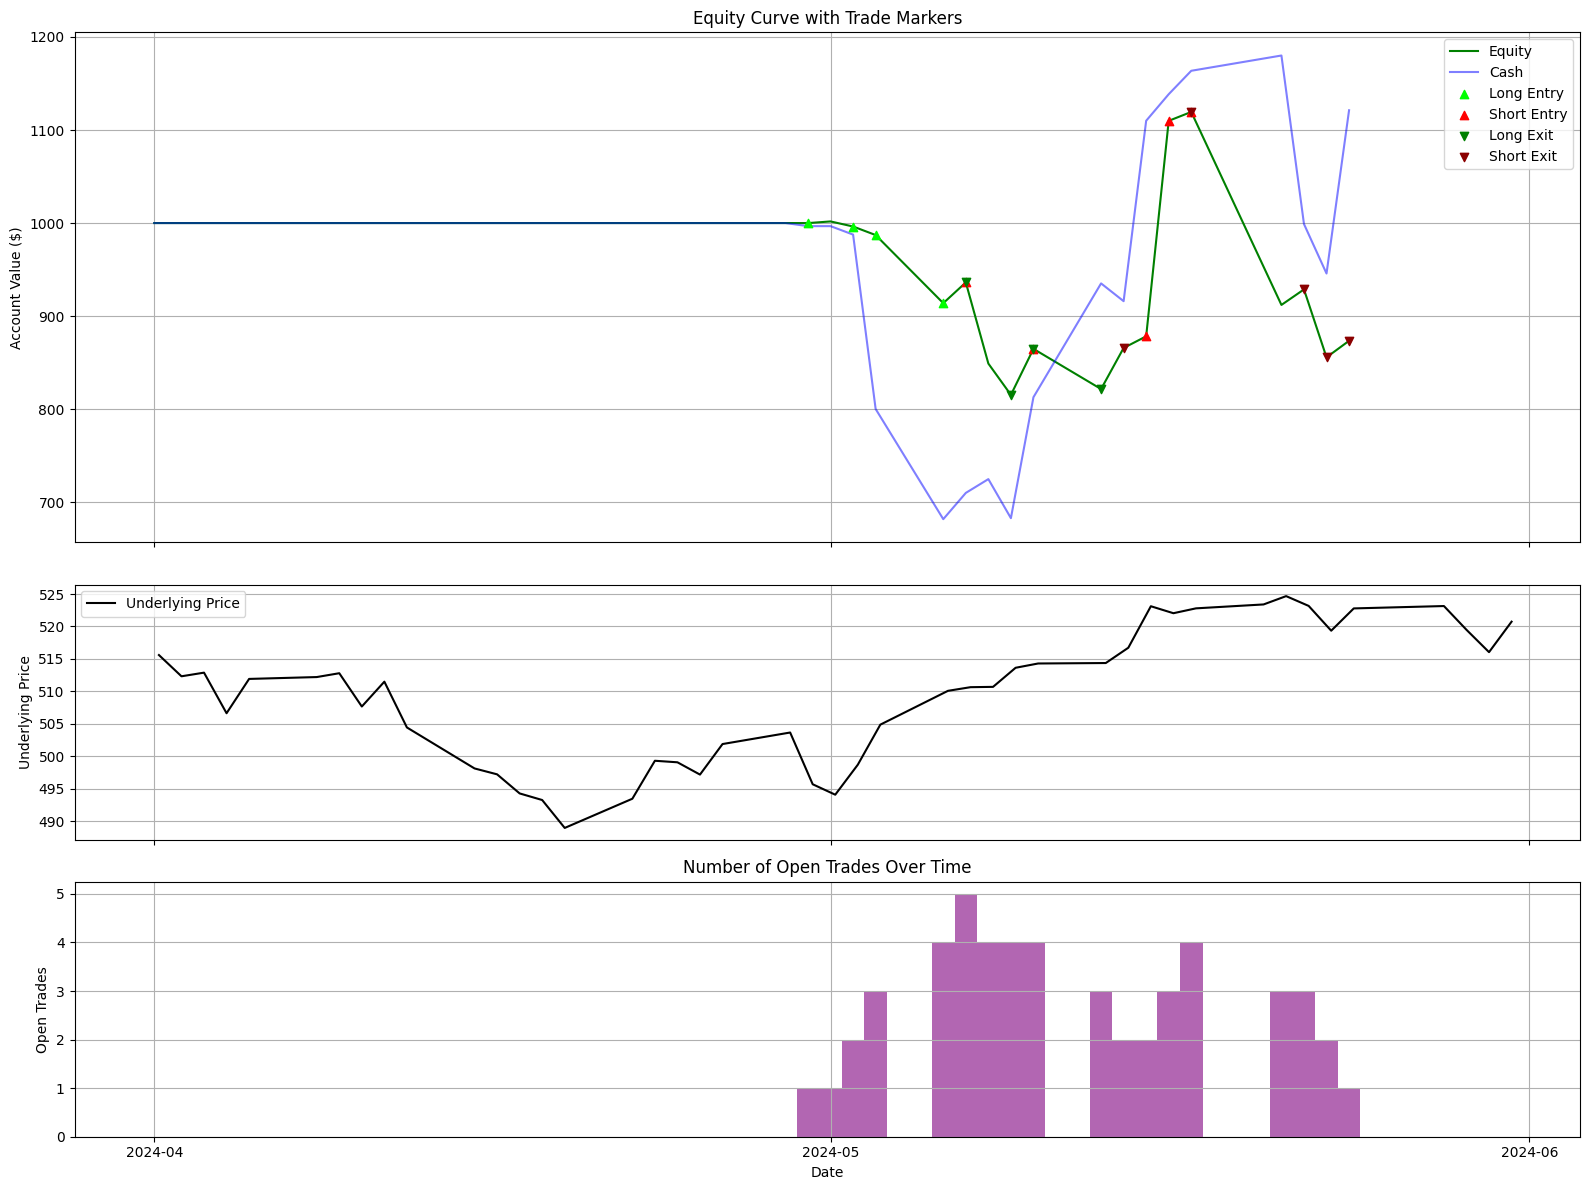

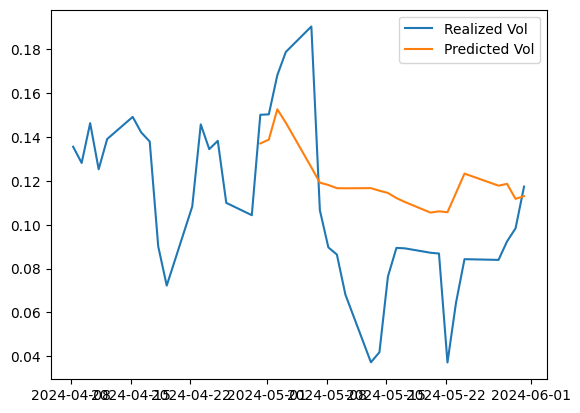

   entry_date   exit_date                    expiry  entry_price  exit_price  \
0  2024-04-30  2024-05-07 2024-05-07 05:00:00+00:00         3.28      -10.01   
1  2024-05-02  2024-05-09 2024-05-09 05:00:00+00:00         0.87       -7.50   
2  2024-05-03  2024-05-10 2024-05-10 05:00:00+00:00        15.58        9.42   
3  2024-05-06  2024-05-13 2024-05-13 05:00:00+00:00         9.83        8.83   
4  2024-05-07  2024-05-14 2024-05-14 05:00:00+00:00       -12.78       -6.37   

   n_butterflies    pnl  underlying_price                strikes  \
0              1 -13.33        495.671356  (482.0, 496.0, 520.0)   
1             10 -84.10        498.682983  (486.0, 499.0, 523.0)   
2             12 -74.40        504.864349  (480.0, 505.0, 530.0)   
3             12 -12.48        510.078033  (490.0, 510.0, 530.0)   
4              3  19.11        510.640839  (490.0, 511.0, 530.0)   

   option_prices_entry    option_prices_exit  pred_vol_entry  commission  \
0  (25.74, 11.3, 0.14)   (35.0, 22

In [14]:
from Butterfly_long_and_short_backtest import ButterflyBacktest_long_short


# Make sure your DataFrames are loaded and preprocessed:
# options_data, underlying_data, vol_predictions




# Instantiate the backtest class
bt_sl = ButterflyBacktest_long_short(
    options_data = options_data, 
    underlying_data = underlying_data, 
    vol_predictions = vol_predictions, 
    spread_pct=5,                                # Tune 
    commission=0.01, 
    slippage=0.0, 
    min_open_interest=0, 
    min_volume=0, 
    vol_exit_threshold=50, # exit if the predicted volatility changes by more than this percentage, TUNE
    rolling_window=5
) 



# Run the backtest
results_df, equity_df = bt_sl.run(option_type='call', starting_cash=1000)

# Display results
print(results_df.head())
print(equity_df.head())



In [17]:
results_df#equity_df

,entry_date,exit_date,expiry,entry_price,exit_price,n_butterflies,pnl,underlying_price,strikes,option_prices_entry,option_prices_exit,pred_vol_entry,commission,slippage,cash_after_trade,early_exit,trade_type
0,2024-05-10,2024-05-17,2024-05-17 05:00:00+00:00,-17.02,-9.84,1,7.14,514.294373,"(489.0, 514.0, 540.0)","(33.33, 8.17, 0.03)","(40.05, 15.11, 0.01)",0.116611,0.04,0.0,1354.74,False,short
1,2024-05-15,2024-05-22,2024-05-22 05:00:00+00:00,-12.97,-14.01,17,-18.36,523.122009,"(500.0, 523.0, 545.0)","(28.85, 7.97, 0.06)","(28.1, 7.05, 0.01)",0.114495,0.68,0.0,1161.98,False,short
2,2024-05-16,2024-05-23,2024-05-23 05:00:00+00:00,-14.31,-26.59,2,-24.64,522.045654,"(496.0, 522.0, 545.0)","(33.13, 9.43, 0.04)","(33.88, 3.65, 0.01)",0.112140,0.08,0.0,1108.80,False,short
3,2024-05-17,2024-05-24,2024-05-24 05:00:00+00:00,-17.55,-19.01,2,-3.00,522.796082,"(497.0, 523.0, 548.0)","(32.77, 7.62, 0.02)","(31.92, 6.46, 0.01)",0.110358,0.08,0.0,1305.63,False,short
4,2024-06-04,2024-06-11,2024-06-11 05:00:00+00:00,-7.86,0.63,3,25.35,521.749451,"(505.0, 522.0, 547.0)","(23.99, 8.08, 0.03)","(28.16, 14.4, 0.01)",0.132246,0.12,0.0,1655.99,False,short
5,2024-06-06,2024-06-13,2024-06-13 05:00:00+00:00,-9.44,-4.68,1,4.72,527.940674,"(509.0, 528.0, 554.0)","(26.43, 8.52, 0.05)","(33.49, 14.41, 0.01)",0.118228,0.04,0.0,1686.59,False,short
6,2024-06-07,2024-06-14,2024-06-14 05:00:00+00:00,-15.96,-10.83,6,30.54,527.298767,"(501.0, 527.5, 553.0)","(33.15, 8.61, 0.03)","(40.48, 14.83, 0.01)",0.112905,0.24,0.0,1731.17,False,short
7,2024-06-10,2024-06-17,2024-06-17 05:00:00+00:00,-12.30,-4.90,2,14.72,528.928040,"(505.0, 529.0, 555.0)","(28.58, 8.15, 0.02)","(40.33, 17.72, 0.01)",0.116011,0.08,0.0,1721.37,False,short
8,2024-06-13,2024-06-20,2024-06-20 05:00:00+00:00,-17.68,-17.62,2,0.04,535.632751,"(508.0, 536.0, 560.0)","(33.28, 7.81, 0.02)","(38.83, 10.61, 0.01)",0.113367,0.08,0.0,1686.13,False,short
9,2024-06-14,2024-06-21,2024-06-21 05:00:00+00:00,-18.30,-18.61,6,-2.10,535.958618,"(509.0, 536.0, 560.0)","(32.72, 7.22, 0.02)","(35.6, 8.5, 0.01)",0.116203,0.24,0.0,1751.87,False,short


## model tryout

In [13]:

%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [14]:
import tensorflow as tf

ImportError: Traceback (most recent call last):
  File "c:\Users\pauli\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [ ]:
loaded_model = tf.keras.models.load_model(r"C:\Users\pauli\Butterflies-\model\models\model1.h5")

NameError: name 'tf' is not defined

## Visualization Tools

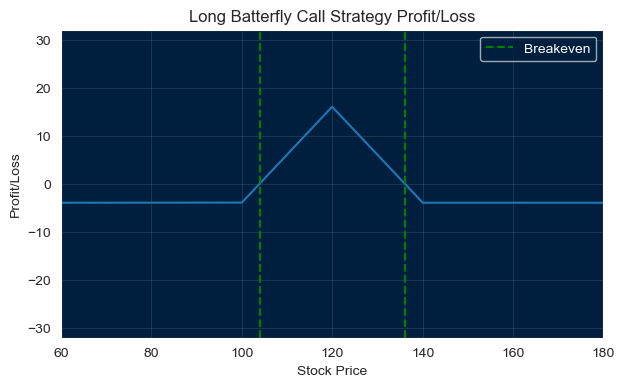

Net Cost/Credit: -3.9593731000237256
Profit if price will be between 103.95844395844395 and 136.04155604155605
Loss if price will be lower than 103.95844395844395 or higher than 136.04155604155605


In [ ]:
#------------------------------------------------
# # play with option strategy 
#-----------------------------------------------
from OptionStrategyfunctions import OptionStrategy

# OptionStrategy(Price_underlying,risk_free_rate = , days_to_maturity)


option = OptionStrategy(80,0.1,2)
sigma = 0.189 # adapt as dynamic rolling window (90 days?) 

option.long_butterfly_call(sigma, 100, 120, 140)

